# PHIL-TEXT — Faz 4.4: DistilBERT Fine-Tuning

**Amaç:** Önceden eğitilmiş DistilBERT modelini 10 filozofa göre fine-tune etmek ve TF-IDF baseline ile karşılaştırmak.

> **GPU önerilir.** CPU'da ~45-90 dakika sürebilir.
> Alternatif: Google Colab (T4 GPU) ile çalıştırılabilir.

### Adımlar
1. Kurulum & Cihaz Kontrolü  
2. Veri Yükleme  
3. Model Konfigürasyonu  
4. Tokenizer Testi  
5. DistilBERT Fine-Tuning  
6. Eğitim Geçmişi Görselleştirme  
7. Test Seti Değerlendirmesi  
8. Baseline ile Karşılaştırma  
9. Meta Kaydetme  
10. Özet Rapor

## 1. Kurulum & Cihaz Kontrolü

In [1]:
import sys, os, json, time, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM     : {vram:.1f} GB')
else:
    print('GPU yok — CPU kullanilacak (yavas, sabir gerektirir)')

from src.models.train    import train_transformer, save_transformer, load_transformer
from src.models.evaluate import evaluate_classification, evaluate_transformer, plot_confusion_matrix

plt.rcParams['figure.dpi'] = 130
sns.set_theme(style='whitegrid', palette='muted')

PyTorch  : 2.10.0+cu126
CUDA     : True
GPU      : NVIDIA GeForce RTX 2050
VRAM     : 4.3 GB


## 2. Veri Yükleme

In [2]:
data = np.load('../data/processed/splits.npz', allow_pickle=True)

# Transformer list + int gerektirir
X_train = data['X_train'].tolist()
y_train = data['y_train'].tolist()
X_val   = data['X_val'].tolist()
y_val   = data['y_val'].tolist()
X_test  = data['X_test'].tolist()
y_test  = data['y_test'].tolist()

with open('../data/processed/label_mappings.json', encoding='utf-8') as f:
    mappings = json.load(f)
id2label   = {v: k for k, v in mappings['philosopher'].items()}
num_labels = len(id2label)

print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')
print(f'Sinif sayisi : {num_labels}')
print(f'Siniflar     : {list(id2label.values())}')

Train: 2,898 | Val: 621 | Test: 621
Sinif sayisi : 10
Siniflar     : ['aristoteles', 'descartes', 'hume', 'kant', 'locke', 'marcus_aurelius', 'nietzsche', 'platon', 'schopenhauer', 'spinoza']


## 3. Model Konfigürasyonu

In [3]:
MODEL_NAME = 'distilbert-base-uncased'   # bert-base-uncased daha iyi ama 2x yavas
OUTPUT_DIR = '../models/saved/distilbert'

EPOCHS     = 3
BATCH_SIZE = 16
LR         = 3e-5
MAX_LEN    = 256   # 512 yerine 256 → hiz/bellek dengesi

print(f'Model        : {MODEL_NAME}')
print(f'Epochs       : {EPOCHS}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Learning rate: {LR}')
print(f'Max length   : {MAX_LEN}')
print(f'Output dir   : {OUTPUT_DIR}')

Model        : distilbert-base-uncased
Epochs       : 3
Batch size   : 16
Learning rate: 3e-05
Max length   : 256
Output dir   : ../models/saved/distilbert


## 4. Tokenizer Testi

In [4]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
sample    = X_train[0]
encoded   = tokenizer(sample, truncation=True, max_length=MAX_LEN, padding='max_length')

print(f'Tokenizer tipi : {tokenizer.__class__.__name__}')
print(f'Vocab boyutu   : {tokenizer.vocab_size:,}')
print(f'Ornek metin    : {sample[:80]}...')
print(f'Token sayisi   : {sum(encoded["attention_mask"])}/{MAX_LEN} (padding haric)')
print(f'Ilk 10 token   : {tokenizer.convert_ids_to_tokens(encoded["input_ids"][:10])}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer tipi : BertTokenizer
Vocab boyutu   : 30,522
Ornek metin    : be discreditable to myself, and to you, and to the whole state. One who has reac...
Token sayisi   : 256/256 (padding haric)
Ilk 10 token   : ['[CLS]', 'be', 'disc', '##red', '##ita', '##ble', 'to', 'myself', ',', 'and']


## 5. DistilBERT Fine-Tuning

> `train_transformer()` fonksiyonu `src/models/train.py` içinde tanımlıdır.  
> Her epoch sonunda en iyi val accuracy'deki model `OUTPUT_DIR`'a kaydedilir.

In [5]:
print('=' * 55)
print('  DistilBERT Fine-Tuning Baslatiyor')
print('=' * 55)

t0 = time.time()
ft_results = train_transformer(
    train_texts   = X_train,
    train_labels  = y_train,
    val_texts     = X_val,
    val_labels    = y_val,
    model_name    = MODEL_NAME,
    num_labels    = num_labels,
    epochs        = EPOCHS,
    batch_size    = BATCH_SIZE,
    learning_rate = LR,
    max_length    = MAX_LEN,
    output_dir    = OUTPUT_DIR,
)
elapsed = time.time() - t0

print(f'\nEgitim suresi       : {elapsed/60:.1f} dakika')
print(f'En iyi val accuracy : {ft_results["best_val_accuracy"]:.4f}')

2026-03-01 22:32:03.232 | INFO     | src.models.train:train_transformer:53 - Transformer egitim: distilbert-base-uncased | cuda | 3 epoch


  DistilBERT Fine-Tuning Baslatiyor


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

2026-03-01 22:38:10.218 | INFO     | src.models.train:train_transformer:111 - Epoch 2/3 | Train Loss: 0.3620 | Val Acc: 0.9211


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2026-03-01 22:40:51.649 | INFO     | src.models.train:train_transformer:111 - Epoch 3/3 | Train Loss: 0.1453 | Val Acc: 0.9469


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Egitim suresi       : 8.8 dakika
En iyi val accuracy : 0.9469


## 6. Eğitim Geçmişi Görselleştirme

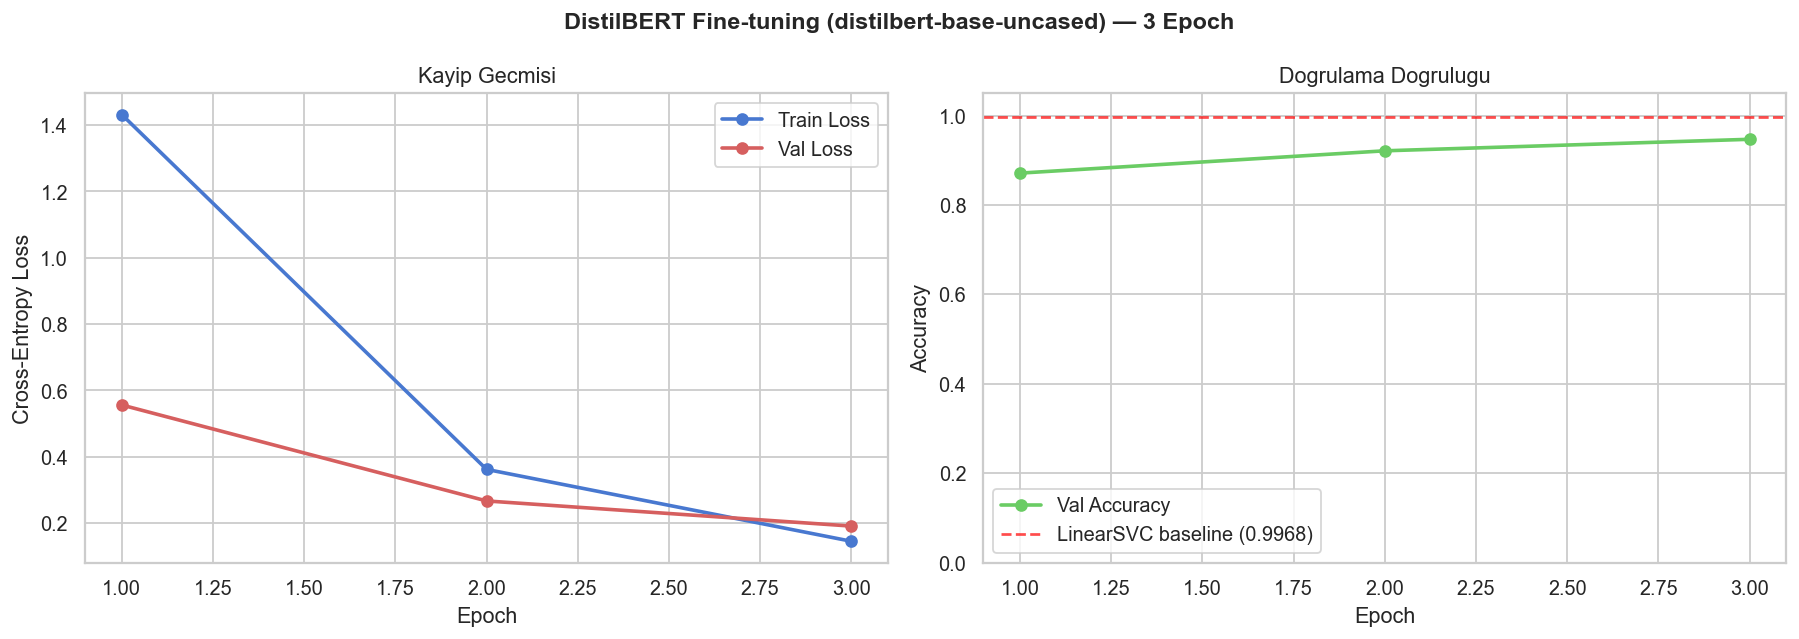

In [6]:
history  = ft_results['history']
ep_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kayip grafigi
axes[0].plot(ep_range, history['train_loss'], 'b-o', linewidth=2, label='Train Loss')
axes[0].plot(ep_range, history['val_loss'],   'r-o', linewidth=2, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Kayip Gecmisi')
axes[0].legend()

# Dogruluk grafigi
axes[1].plot(ep_range, history['val_accuracy'], 'g-o', linewidth=2, label='Val Accuracy')
axes[1].axhline(0.9968, color='red', linestyle='--', alpha=0.7,
                label='LinearSVC baseline (0.9968)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Dogrulama Dogrulugu')
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.suptitle(f'DistilBERT Fine-tuning ({MODEL_NAME}) — {EPOCHS} Epoch',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/bert_training_history.png', bbox_inches='tight')
plt.show()

## 7. Test Seti Değerlendirmesi

In [7]:
print('=== TEST SETI DEGERLENDIRMESI ===')
bert_model, bert_tok = load_transformer(OUTPUT_DIR)

test_metrics = evaluate_transformer(
    bert_model, bert_tok, X_test, y_test,
    id2label=id2label, max_length=MAX_LEN
)

print(f'DistilBERT Test Accuracy : {test_metrics["accuracy"]:.4f}')
print(f'DistilBERT Test F1 (W)   : {test_metrics["f1_weighted"]:.4f}')
print(f'DistilBERT Test F1 (M)   : {test_metrics["f1_macro"]:.4f}')
print()
print(test_metrics['report'])

=== TEST SETI DEGERLENDIRMESI ===


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

2026-03-01 22:41:08.007 | INFO     | src.models.evaluate:evaluate_classification:17 - Accuracy: 0.9388 | F1: 0.9353


DistilBERT Test Accuracy : 0.9388
DistilBERT Test F1 (W)   : 0.9353
DistilBERT Test F1 (M)   : 0.8760

                 precision    recall  f1-score   support

    aristoteles       0.95      0.95      0.95        83
      descartes       1.00      0.20      0.33        10
           hume       0.93      0.99      0.96        88
           kant       0.97      0.95      0.96        87
          locke       1.00      0.96      0.98        53
marcus_aurelius       0.91      0.91      0.91        23
      nietzsche       0.99      0.93      0.96        74
         platon       0.96      0.98      0.97       111
   schopenhauer       0.82      0.89      0.85        62
        spinoza       0.87      0.90      0.89        30

       accuracy                           0.94       621
      macro avg       0.94      0.87      0.88       621
   weighted avg       0.94      0.94      0.94       621



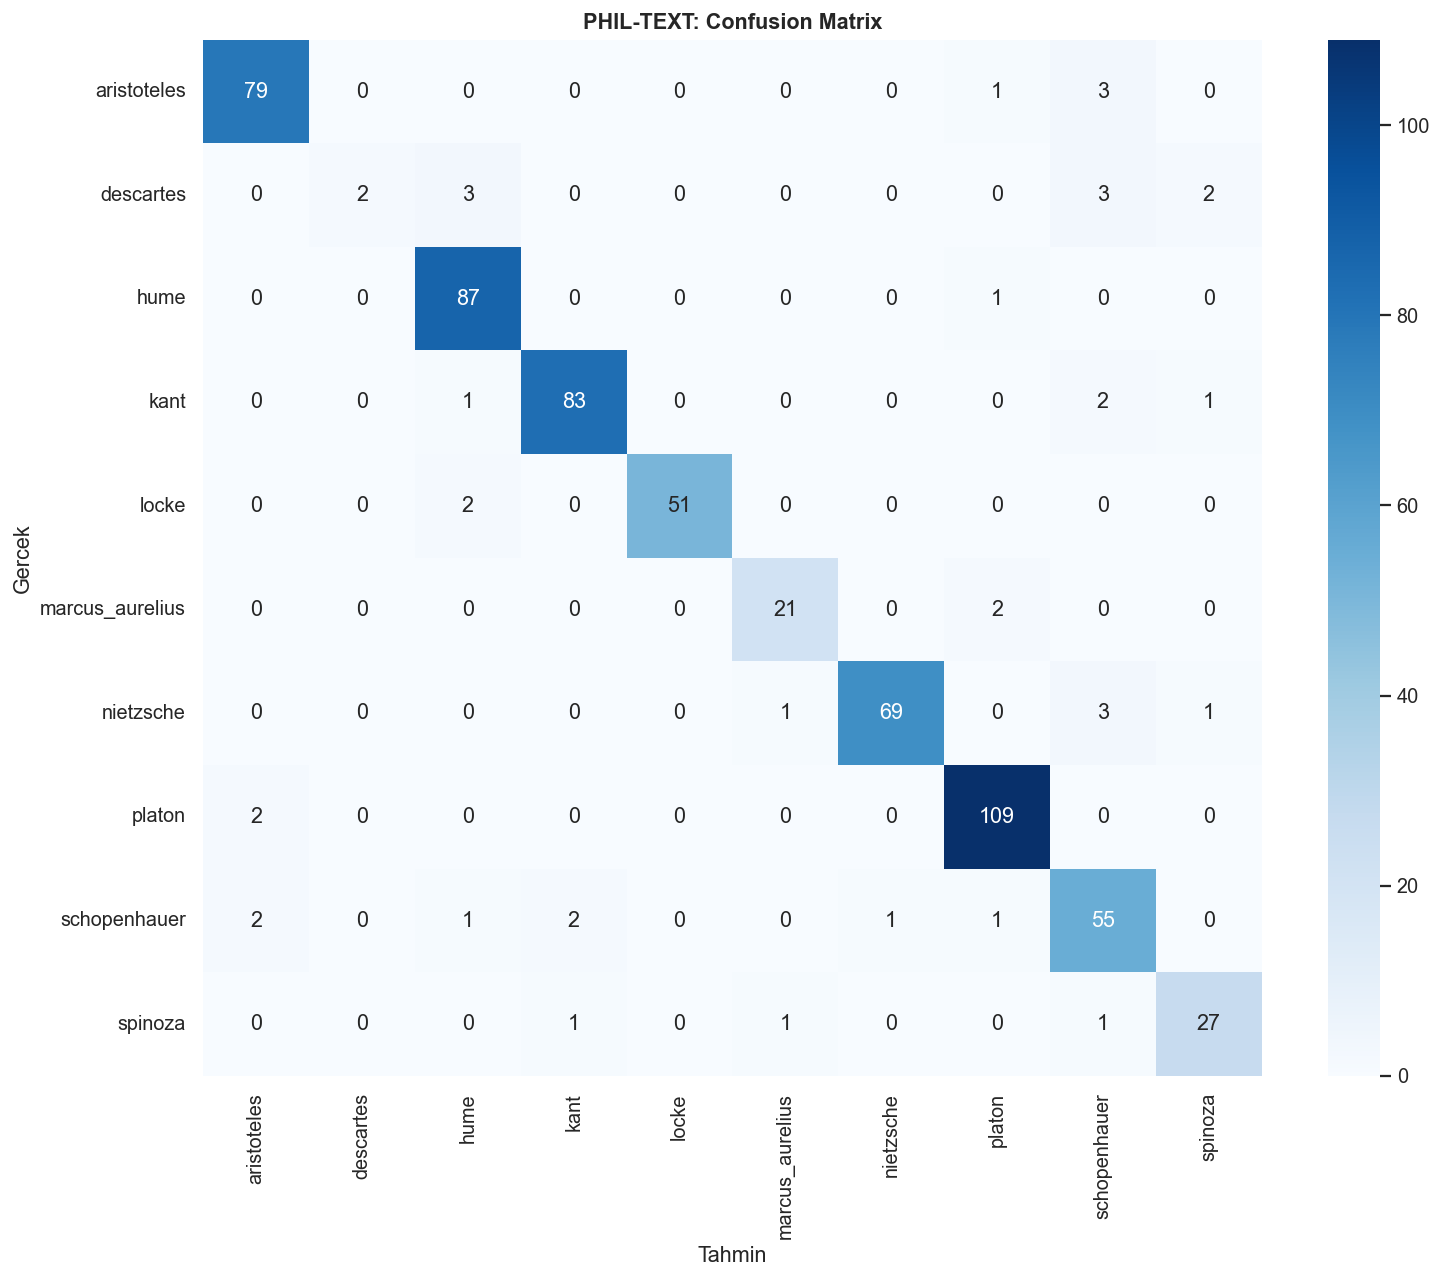

In [8]:
cm = plot_confusion_matrix(
    y_test,
    test_metrics['predictions'],
    id2label,
    save_path='../docs/bert_confusion_matrix.png'
)

## 8. Baseline ile Karşılaştırma

                        accuracy  f1_weighted
LinearSVC (baseline)    0.998390     0.998353
DistilBERT (fine-tune)  0.938808     0.935289


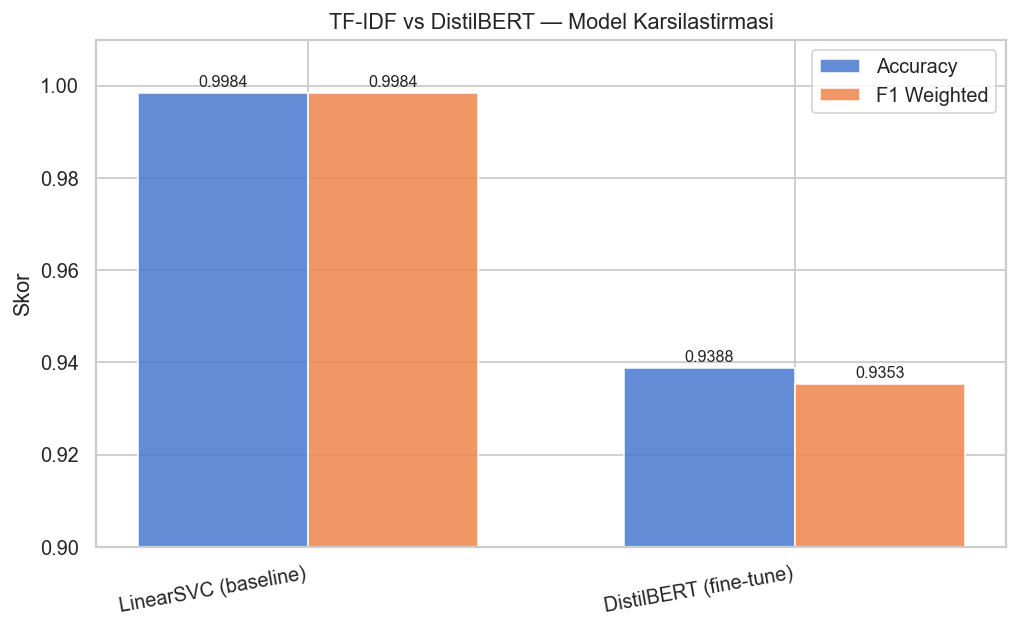

In [9]:
from sklearn.metrics import accuracy_score, f1_score

baseline = joblib.load('../models/best_model_linearsvc.joblib')
base_pred = baseline.predict(X_test)
base_acc  = accuracy_score(y_test, base_pred)
base_f1   = f1_score(y_test, base_pred, average='weighted', zero_division=0)

comparison = {
    'LinearSVC (baseline)':  {'accuracy': base_acc,                    'f1_weighted': base_f1},
    'DistilBERT (fine-tune)': {'accuracy': test_metrics['accuracy'], 'f1_weighted': test_metrics['f1_weighted']},
}
comp_df = pd.DataFrame(comparison).T
print(comp_df.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(comp_df))
w = 0.35
bars1 = ax.bar(x - w/2, comp_df['accuracy'],    width=w, label='Accuracy',    alpha=0.85)
bars2 = ax.bar(x + w/2, comp_df['f1_weighted'], width=w, label='F1 Weighted', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(comp_df.index, rotation=10, ha='right')
ax.set_ylabel('Skor')
ax.set_title('TF-IDF vs DistilBERT — Model Karsilastirmasi')
ax.set_ylim(0.9, 1.01)
ax.legend()
for bars in [bars1, bars2]:
    ax.bar_label(bars, fmt='%.4f', padding=2, fontsize=9)
plt.tight_layout()
plt.savefig('../docs/bert_vs_baseline.png', bbox_inches='tight')
plt.show()

## 9. Meta Kaydetme

In [10]:
os.makedirs('../models', exist_ok=True)

bert_meta = {
    'model_name':         MODEL_NAME,
    'output_dir':         OUTPUT_DIR,
    'epochs':             EPOCHS,
    'batch_size':         BATCH_SIZE,
    'learning_rate':      LR,
    'max_length':         MAX_LEN,
    'num_labels':         num_labels,
    'best_val_accuracy':  round(ft_results['best_val_accuracy'], 4),
    'test_accuracy':      round(test_metrics['accuracy'],        4),
    'test_f1_weighted':   round(test_metrics['f1_weighted'],     4),
    'baseline_accuracy':  round(base_acc, 4),
    'baseline_f1':        round(base_f1,  4),
}
with open('../models/bert_meta.json', 'w') as f:
    json.dump(bert_meta, f, indent=2)

print(f'Model: {OUTPUT_DIR}')
print(f'Meta : models/bert_meta.json')
print()
for k, v in bert_meta.items():
    print(f'  {k:<25}: {v}')

Model: ../models/saved/distilbert
Meta : models/bert_meta.json

  model_name               : distilbert-base-uncased
  output_dir               : ../models/saved/distilbert
  epochs                   : 3
  batch_size               : 16
  learning_rate            : 3e-05
  max_length               : 256
  num_labels               : 10
  best_val_accuracy        : 0.9469
  test_accuracy            : 0.9388
  test_f1_weighted         : 0.9353
  baseline_accuracy        : 0.9984
  baseline_f1              : 0.9984


## 10. Özet Rapor

In [11]:
diff = test_metrics['accuracy'] - base_acc

print('=' * 60)
print('  FAZ 4.4 — DISTILBERT FINE-TUNING OZET RAPORU')
print('=' * 60)
print(f'  Model         : {MODEL_NAME}')
print(f'  Epoch         : {EPOCHS} | LR: {LR} | MaxLen: {MAX_LEN}')
print()
print(f'  LinearSVC     : Acc={base_acc:.4f}  F1(W)={base_f1:.4f}')
print(f'  DistilBERT    : Acc={test_metrics["accuracy"]:.4f}  F1(W)={test_metrics["f1_weighted"]:.4f}')
print(f'  Fark (acc)    : {diff:+.4f}')
print()
print('  Sonraki: Faz 5 — FastAPI Deployment')
print('=' * 60)

  FAZ 4.4 — DISTILBERT FINE-TUNING OZET RAPORU
  Model         : distilbert-base-uncased
  Epoch         : 3 | LR: 3e-05 | MaxLen: 256

  LinearSVC     : Acc=0.9984  F1(W)=0.9984
  DistilBERT    : Acc=0.9388  F1(W)=0.9353
  Fark (acc)    : -0.0596

  Sonraki: Faz 5 — FastAPI Deployment
